# TUTOR DE PAPERS CIENTÍFICOS — un asistente que explica artículos de investigación sección por sección

*Por Cristhian Daniel Guevara Cano*

Este proyecto consiste en un **tutor que ayuda a estudiar artículos científicos**, explicando cada fragmento del paper y desarrollando los conceptos técnicos que el lector no conoce, citando siempre de dónde sale cada dato.

| Pieza | Concepto del curso | Qué hace en el Tutor de Papers |
|---|---|---|
| ① | **RAG interno** (sentence-transformers) | Indexa el PDF subido por secciones/oraciones, para recuperar el fragmento exacto relevante a cada pregunta |
| ② | **RAG externo** (sentence-transformers) | Busca definiciones en un glosario curado de ML/IA, con umbral de similitud para admitir honestamente cuando un término no está cubierto |
| ③ | **Fine-tuning clasificador** (DistilBERT multilingüe + LoRA) | Etiqueta cada fragmento del paper con su **rol retórico**: OBJETIVO, TRABAJO_RELACIONADO, METODOLOGIA, RESULTADO, DISCUSION o CONCLUSION — así la explicación se adapta al tipo de contenido |
| ④ | **Fine-tuning generativo** (TinyLlama + LoRA, demostración) | Ajusta el *tono* de un modelo generativo pequeño con `SFTTrainer`, como ejercicio independiente que muestra la técnica de LoRA sobre un modelo causal, distinto del clasificador |
| ⑤ | **Prompt** (Groq · gpt-oss-20b) | Redacta la explicación final en voz de tutor, citando explícitamente si el dato viene del **paper**, del **glosario** o de **conocimiento general** |
| ⑥ | **Evaluación** (matriz de confusión + Groq-juez) | Mide qué tan bien clasifica el rol retórico, y si el tutor cumple la regla de honestidad sobre sus fuentes |

> **La idea clave:** el clasificador de rol retórico no decide *quién* contesta, decide *cómo* explicar — enfocándose en el "por qué" si es objetivo, el "cómo" si es metodología, la interpretación si es resultado, etc. Y una **regla de fuente de dos niveles** gobierna toda respuesta: si el dato está en el paper o el glosario, se cita explícitamente; si no, se admite con honestidad antes de dar una definición general — el tutor nunca inventa ni finge certeza sobre algo que no verificó.

### El plan de desarrollo

`Instalar → Llave de Groq → Glosario → RAG (paper + glosario) → Dataset rol retórico → Clasificador (antes) → LoRA + Entrenar → (después + matriz) → LoRA generativo sobre Llama (demo de tono) → Voz del tutor + pipeline → Juez → App Gradio`

> Corre en **CPU**, excepto el paso de LoRA generativo sobre TinyLlama (Paso 9.5), que necesita **GPU** (Colab → Entorno de ejecución → GPU T4).
> La única llave necesaria es **GROQ_API_KEY** (gratis en groq.com).
> Los papers pueden estar en **inglés o español** — el clasificador y los embeddings son multilingües.
> Para correr toda la notebook, se necesita subir en archivos un pdf para realizar lar pruebas internas. Al usar la aplicación el pdf se sube directamente.

## Paso 1 · Instalar las herramientas
Hugging Face (entrenar + clasificar), sentence-transformers (RAG), Groq (redactar), Gradio (la app), pymupdf (leer pdf) y spacy (dividir texto).

In [ ]:
# torchao de Colab a veces choca con peft → lo quitamos para evitar el error
# pymupdf extrae texto de pdfs
# spacy para dividir el texto en oraciones (sentence segmentation)
#%%capture
!pip uninstall -y torchao
!pip install -q transformers peft datasets sentence-transformers groq "gradio>=6,<7" pymupdf spacy

## Paso 2 · Llave Groq

In [ ]:
import os, time
from getpass import getpass
from groq import Groq
from google.colab import userdata

groq_client = Groq(api_key=userdata.get('GROQ_API_KEY'))
GROQ_MODEL = "openai/gpt-oss-20b"   # modelo abierto, el mismo de la Clase 2

def preguntar_a_groq(prompt, temperatura=0.4):
    """Manda un prompt a Groq y regresa el texto. Si el plan gratis te frena, espera y reintenta una vez."""
    for intento in (1, 2):
        try:
            r = groq_client.chat.completions.create(
                model=GROQ_MODEL,
                messages=[{"role": "user", "content": prompt}],
                temperature=temperatura,
                reasoning_format="hidden",  # gpt-oss-20b es un modelo de razonamiento; esto evita que
                                             # su cadena de pensamiento se mezcle con la respuesta final
            )
            return r.choices[0].message.content.strip()
        except Exception as e:
            if intento == 1:
                print("Groq se tardó o te frenó; espero 5 seg y reintento…")
                time.sleep(5)
            else:
                return f"(No pude contestar: {type(e).__name__}. Revisa tu llave o espera un minuto.)"

print("Groq listo ✅  ·  modelo:", GROQ_MODEL)

Groq listo ✅  ·  modelo: openai/gpt-oss-20b


## Paso 3 · Carga y extracción del PDF
Extraemos el texto del paper que queremos analizar. El sistema basará sus respuestas en el paper.

In [ ]:
import fitz  # pymupdf

def extraer_texto_pdf(ruta_pdf):
    """Abre un PDF y regresa una lista de (numero_de_pagina, texto) por cada página."""
    doc = fitz.open(ruta_pdf)
    paginas = []
    for i, pagina in enumerate(doc):
        texto = pagina.get_text("text")
        paginas.append((i + 1, texto))
    doc.close()
    return paginas


def unir_texto(paginas):
    """Junta todas las páginas en un solo string, insertando marcadores de página."""
    return "\n\n".join(f"[PÁGINA {num}]\n{texto.strip()}" for num, texto in paginas)


# Prueba (se necesita subir un PDF a Colab primero, ej. arrastrándolo al panel de archivos)
ruta = "/content/An_Overview_of_Neural_Network.pdf"
paginas = extraer_texto_pdf(ruta)
PAPER = unir_texto(paginas)
print(f"PDF cargado ✅ · {len(paginas)} páginas · {len(PAPER)} caracteres")
print("\nMuestra de la primera página:\n")
print(PAPER[:500])

PDF cargado ✅ · 5 páginas · 21465 caracteres

Muestra de la primera página:

[PÁGINA 1]
American Journal of Neural Networks and Applications
2019; 5(1): 7-11 
http://www.sciencepublishinggroup.com/j/ajnna 
doi: 10.11648/j.ajnna.20190501.12 
ISSN: 2469-7400 (Print); ISSN: 2469-7419 (Online) 
 
An Overview of Neural Network 
Mohaiminul Islam, Guorong Chen, Shangzhu Jin 
School of Intelligent Technology and Engineering, Chongqing University of Science and Technology, Chongqing, China 
Email address: 
 
To cite this article: 
Mohaiminul Islam, Guorong Chen, Shangzhu Jin. An 


## Paso 4 · El glosario técnico

Un texto fijo que sirve como fuente de verdad para las definiciones. A diferencia del PDF (que cambia cada vez que el usuario sube uno), el glosario se indexa una sola vez al inicio y se reutiliza para todos los papers futuros.

In [ ]:
GLOSARIO = """GLOSARIO DE CONCEPTOS DE MACHINE LEARNING E IA

== OVERFITTING (SOBREAJUSTE) ==
Overfitting o sobreajuste: cuando un modelo aprende tan bien los datos de entrenamiento
que memoriza ruido y detalles específicos en vez de patrones generales, y por eso
funciona mal con datos nuevos que no ha visto. Se detecta cuando el error de
entrenamiento sigue bajando pero el error de validación empieza a subir.

== REGULARIZACIÓN (L1 / L2) ==
Regularización: técnica para reducir el overfitting penalizando modelos demasiado
complejos durante el entrenamiento.
L1 (Lasso): suma el valor absoluto de los pesos a la función de pérdida; tiende a
volver algunos pesos exactamente cero (selección de variables).
L2 (Ridge / weight decay): suma el cuadrado de los pesos a la función de pérdida;
encoge todos los pesos hacia valores pequeños sin volverlos cero.

== VALIDACIÓN CRUZADA (CROSS-VALIDATION) ==
Validación cruzada: método para evaluar qué tan bien generaliza un modelo dividiendo
los datos en varios subconjuntos (folds), entrenando en unos y evaluando en el
restante, repitiendo el proceso rotando qué subconjunto se usa para evaluar.
K-fold: variante donde los datos se dividen en K partes iguales.

== DESCENSO DE GRADIENTE (GRADIENT DESCENT) ==
Descenso de gradiente: algoritmo de optimización que ajusta los pesos de un modelo
dando pasos en la dirección opuesta al gradiente de la función de pérdida, para
minimizarla poco a poco.
Learning rate (tasa de aprendizaje): qué tan grande es cada paso; muy alto puede
hacer que el entrenamiento diverja, muy bajo lo hace lento.
Batch size: cuántos ejemplos se usan para calcular cada paso de actualización.
Epoch (época): una pasada completa por todo el conjunto de entrenamiento.

== FUNCIÓN DE PÉRDIDA (LOSS FUNCTION) ==
Función de pérdida: mide qué tan lejos están las predicciones del modelo de los
valores reales; el entrenamiento busca minimizarla.
Cross-entropy (entropía cruzada): función de pérdida estándar para clasificación;
penaliza fuerte cuando el modelo está muy seguro de una respuesta incorrecta.
MSE (error cuadrático medio): función de pérdida estándar para regresión.

== MÉTRICAS DE CLASIFICACIÓN ==
Precisión (precision): de todo lo que el modelo predijo como positivo, qué
proporción realmente lo era.
Exhaustividad (recall): de todo lo que realmente era positivo, qué proporción
el modelo detectó.
F1-score: media armónica entre precisión y exhaustividad; útil cuando las clases
están desbalanceadas.
Matriz de confusión: tabla que cruza predicciones contra valores reales, mostrando
aciertos y tipos de error por clase.

== ARQUITECTURAS DE REDES NEURONALES ==
CNN (red neuronal convolucional): arquitectura especializada en datos con
estructura espacial (como imágenes), usa filtros que se deslizan sobre la entrada.
RNN / LSTM / GRU: arquitecturas para datos secuenciales (texto, series de tiempo);
LSTM y GRU agregan mecanismos de "memoria" para recordar información de pasos
anteriores en la secuencia.
Transformer: arquitectura basada en mecanismos de atención (no en recurrencia),
que procesa toda la secuencia en paralelo; es la base de modelos como BERT y GPT.
Mecanismo de atención (attention): permite al modelo "enfocarse" en las partes más
relevantes de la entrada al procesar cada elemento de la secuencia.

== TRANSFER LEARNING ==
Transfer learning (aprendizaje por transferencia): reutilizar un modelo ya
entrenado en una tarea grande (como entender lenguaje en general) como punto de
partida para una tarea nueva y más específica.

== FINE-TUNING ==
Fine-tuning (afinado): ajustar los pesos de un modelo preentrenado con un dataset
más pequeño y específico de la tarea nueva.

== LORA ==
LoRA (Low-Rank Adaptation): técnica de fine-tuning eficiente que congela los pesos
originales del modelo y solo entrena matrices pequeñas de bajo rango agregadas a
ciertas capas, reduciendo drásticamente cuántos parámetros hay que entrenar.

== EMBEDDINGS Y SIMILITUD ==
Embedding: representación numérica (un vector) de una palabra, oración o
documento, donde elementos con significado parecido quedan cerca en el espacio
vectorial.
Similitud coseno (cosine similarity): medida de qué tan parecidos son dos vectores
según el ángulo entre ellos, usada para comparar embeddings.

== EVALUACIÓN ESTADÍSTICA ==
P-valor (p-value): probabilidad de observar un resultado igual o más extremo que
el obtenido, asumiendo que no hay efecto real (hipótesis nula); un p-valor bajo
(comúnmente <0.05) se interpreta como evidencia contra la hipótesis nula.
Baseline: modelo o método simple usado como punto de referencia para saber si un
modelo nuevo realmente aporta una mejora.
SOTA (state of the art): el mejor resultado reportado hasta el momento en una
tarea o benchmark específico.
Ablation study (estudio de ablación): experimento donde se quita o desactiva una
parte del modelo/método para medir cuánto contribuía esa parte al resultado final.
"""

print("Glosario cargado ✅ ·", len(GLOSARIO), "caracteres")

Glosario cargado ✅ · 4912 caracteres


## Paso 5 · RAG — indexar el paper y el glosario

Se tienen dos fuentes con estructuras distintas: el glosario (texto limpio, escrito personalmente, con encabezados uniformes) y el paper (texto extraído de PDF, con estructura impredecible — algunos usan "1. Introduction", otros "Abstract", otros numeración romana, y muchos ni siquiera tienen encabezados detectables en el texto plano extraído).

Se usarán dos estrategias de troceo distintas, aunque ambas terminan alimentando la misma función de búsqueda semántica.

### 5.1 · Troceo del glosario

In [ ]:
def trocear(texto):
    """Trocea un texto con encabezados '== TÍTULO ==' en bloques por sección."""
    chunks, actual = [], []
    for linea in texto.split("\n"):
        if linea.startswith("== ") and linea.endswith(" =="):
            if actual: chunks.append("\n".join(actual).strip())
            actual = [linea]
        else:
            actual.append(linea)
    if actual: chunks.append("\n".join(actual).strip())
    return [c for c in chunks if c]

secciones_glosario = trocear(GLOSARIO)

In [ ]:
print(len(secciones_glosario), "entradas del glosario (después de separar) ✅")

13 entradas del glosario (después de separar) ✅


### 5.2 · Troceo del paper

Dividimos por oración, usando spacy, y agrupamos oraciones consecutivas hasta llegar a un tamaño objetivo — una técnica estándar de chunking en RAG cuando el documento no tiene estructura confiable.

In [ ]:
import spacy

nlp_frases = spacy.blank("xx")       # pipeline "en blanco", sin modelo de idioma específico
nlp_frases.add_pipe("sentencizer")   # componente basado en reglas de puntuación

def dividir_en_oraciones(texto):
    """Separa un bloque de texto en oraciones, sin depender de un idioma fijo."""
    doc = nlp_frases(texto)
    return [oracion.text.strip() for oracion in doc.sents if oracion.text.strip()]

def trocear_paper(paginas, tam_objetivo=400):
    """
    Divide el texto de cada página en chunks de ~tam_objetivo caracteres,
    respetando límites de oración y conservando el número de página de origen.
    """
    chunks = []
    for num_pagina, texto in paginas:
        buffer = ""
        for oracion in dividir_en_oraciones(texto):
            if len(buffer) + len(oracion) > tam_objetivo and buffer:
                chunks.append({"texto": buffer.strip(), "pagina": num_pagina})
                buffer = ""
            buffer += " " + oracion
        if buffer.strip():
            chunks.append({"texto": buffer.strip(), "pagina": num_pagina})
    return chunks

secciones_paper = trocear_paper(paginas)

### 5.3 · Embeddings y funciones de búsqueda

In [ ]:
from sentence_transformers import SentenceTransformer, util

buscador = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

# Índice del glosario
emb_glosario = buscador.encode(secciones_glosario, convert_to_tensor=True)

# Índice del paper (encode() solo recibe texto, así que extraemos los textos primero)
textos_paper = [c["texto"] for c in secciones_paper]
emb_paper = buscador.encode(textos_paper, convert_to_tensor=True)



Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Funciones de buscar (embedding de la query → semantic_search contra el índice → mapear índices de vuelta al texto), solo que buscar_en_paper devuelve los diccionarios con página incluida.

In [ ]:
def buscar_en_paper(pregunta, k=3):
    """Regresa los k fragmentos del paper más relevantes, cada uno con su página de origen."""
    emb_q = buscador.encode(pregunta, convert_to_tensor=True)
    hits = util.semantic_search(emb_q, emb_paper, top_k=k)[0]
    return [secciones_paper[h["corpus_id"]] for h in hits]

def buscar_definicion(termino, k=2, umbral=0.35):
    """Regresa las definiciones del glosario relevantes para un término,
    o una lista vacía si ninguna supera el umbral de similitud."""
    emb_q = buscador.encode(termino, convert_to_tensor=True)
    hits = util.semantic_search(emb_q, emb_glosario, top_k=k)[0]
    hits_relevantes = [h for h in hits if h["score"] >= umbral]
    return [secciones_glosario[h["corpus_id"]] for h in hits_relevantes]

In [ ]:
# Pruebas
print(len(secciones_paper), "fragmentos del paper indexados ✅")
print(len(secciones_glosario), "términos del glosario indexados ✅")

print("\nEjemplo — busco 'cómo evaluaron el modelo' en el paper:\n")
r = buscar_en_paper("cómo evaluaron el modelo", k=1)[0]
print(f"[Página {r['pagina']}]\n{r['texto']}")

print("\nEjemplo — busco definición de 'overfitting':\n")
print(buscar_definicion("overfitting", k=1)[0])

65 fragmentos del paper indexados ✅
13 términos del glosario indexados ✅

Ejemplo — busco 'cómo evaluaron el modelo' en el paper:

[Página 1]
These models are biologically inspired 
rather than an exact replica of how the brain actually functions. Neural networks have been shown to be very promising systems 
in many forecasting applications and business classification applications due to their ability to learn from the data. This article 
aims to provide a brief overview of artificial neural network.

Ejemplo — busco definición de 'overfitting':

== OVERFITTING (SOBREAJUSTE) ==
Overfitting o sobreajuste: cuando un modelo aprende tan bien los datos de entrenamiento
que memoriza ruido y detalles específicos en vez de patrones generales, y por eso
funciona mal con datos nuevos que no ha visto. Se detecta cuando el error de
entrenamiento sigue bajando pero el error de validación empieza a subir.


## Paso 6 · Dataset de entrenamiento para el clasificador de rol retórico

Aquí se retoma la decisión de la sección anterior sobre fine-tuning: 6 clases (OBJETIVO, TRABAJO_RELACIONADO, METODOLOGIA, RESULTADO, DISCUSION, CONCLUSION), clasificando a nivel oración. Se escriben ejemplos a mano como semilla — mezclando inglés y español a propósito, porque el modelo tiene que aprender a reconocer el rol retórico sin importar el idioma en que esté escrita la oración.

In [ ]:
from datasets import Dataset
# 6 categorías, roles retóricos
CLASES_ROL = ['OBJETIVO', 'TRABAJO_RELACIONADO', 'METODOLOGIA', 'RESULTADO', 'DISCUSION', 'CONCLUSION']
clase2id_rol = {c: i for i, c in enumerate(CLASES_ROL)}
id2clase_rol = {i: c for i, c in enumerate(CLASES_ROL)}

In [ ]:
oraciones_entrenamiento = [
    # OBJETIVO
    ('In this paper, we propose a novel approach to reduce hallucinations in retrieval-augmented generation systems.', 'OBJETIVO'),
    ('El objetivo de este trabajo es evaluar el impacto de LoRA en modelos de clasificación con pocos datos.', 'OBJETIVO'),
    ('This study aims to investigate whether attention mechanisms improve interpretability in transformer-based models.', 'OBJETIVO'),
    ('Nuestro objetivo principal es diseñar un método que reduzca el costo computacional del fine-tuning.', 'OBJETIVO'),
    ('We address the problem of catastrophic forgetting in continual learning settings.', 'OBJETIVO'),
    ('En este artículo buscamos responder si los modelos multilingües generalizan mejor que los monolingües en tareas de clasificación.', 'OBJETIVO'),

    # TRABAJO_RELACIONADO
    ('Previous work by Smith et al. (2021) demonstrated that data augmentation improves generalization in low-resource settings.', 'TRABAJO_RELACIONADO'),
    ('Estudios anteriores han mostrado que los modelos preentrenados transfieren bien a tareas de dominio específico.', 'TRABAJO_RELACIONADO'),
    ('Several approaches have been proposed to address class imbalance, including oversampling and cost-sensitive learning.', 'TRABAJO_RELACIONADO'),
    ('A diferencia de los enfoques anteriores basados en reglas, nuestro método no requiere anotación manual extensa.', 'TRABAJO_RELACIONADO'),
    ('Unlike prior studies that rely solely on accuracy, we also report F1-score per class.', 'TRABAJO_RELACIONADO'),
    ('Trabajos como el de García et al. han explorado RAG en dominios biomédicos con resultados prometedores.', 'TRABAJO_RELACIONADO'),

    # METODOLOGIA
    ('We fine-tuned a DistilBERT model using LoRA with rank r=8 and a learning rate of 5e-4.', 'METODOLOGIA'),
    ('Utilizamos un conjunto de datos de 10,000 oraciones extraídas de artículos científicos en inglés y español.', 'METODOLOGIA'),
    ('The model was trained for 40 epochs with a batch size of 4 on a single GPU.', 'METODOLOGIA'),
    ('Dividimos el corpus en 80% para entrenamiento, 10% para validación y 10% para prueba.', 'METODOLOGIA'),
    ('We used sentence-transformers to generate embeddings for the semantic search component.', 'METODOLOGIA'),
    ('Para evaluar el desempeño, aplicamos validación cruzada de 5 particiones (5-fold cross-validation).', 'METODOLOGIA'),

    # RESULTADO
    ('Our model achieved an accuracy of 91.3% on the held-out test set, outperforming the baseline by 12 points.', 'RESULTADO'),
    ('Los resultados muestran que la precisión aumentó de 68% a 87% después del fine-tuning con LoRA.', 'RESULTADO'),
    ('Table 3 shows that the proposed method reduces inference latency by 40% compared to the full fine-tuning approach.', 'RESULTADO'),
    ('El modelo afinado obtuvo un F1-score de 0.89 en la clase minoritaria, frente a 0.52 del modelo base.', 'RESULTADO'),
    ('These results are statistically significant (p < 0.01) according to a paired t-test.', 'RESULTADO'),
    ('La matriz de confusión revela que la mayoría de los errores ocurren entre las clases DISCUSION y CONCLUSION.', 'RESULTADO'),

    # DISCUSION
    ('These findings suggest that low-rank adaptation is particularly effective when training data is scarce.', 'DISCUSION'),
    ('Sin embargo, una limitación de nuestro enfoque es que depende de un glosario curado manualmente.', 'DISCUSION'),
    ('One possible explanation for this improvement is that LoRA acts as an implicit regularizer.', 'DISCUSION'),
    ('Es importante notar que estos resultados podrían no generalizar a dominios muy distintos al evaluado aquí.', 'DISCUSION'),
    ('A key limitation of this study is the relatively small size of the test set.', 'DISCUSION'),
    ('Esto sugiere que el modelo podría beneficiarse de un preentrenamiento adicional en el dominio específico.', 'DISCUSION'),

    # CONCLUSION
    ('In conclusion, we have shown that parameter-efficient fine-tuning can match full fine-tuning performance at a fraction of the cost.', 'CONCLUSION'),
    ('En conclusión, este trabajo demuestra que RAG combinado con fine-tuning mejora la fidelidad de las respuestas generadas.', 'CONCLUSION'),
    ('Future work will explore extending this approach to multimodal settings involving text and images.', 'CONCLUSION'),
    ('Como trabajo futuro, planeamos evaluar el método en un corpus más grande y diverso.', 'CONCLUSION'),
    ('Overall, our results highlight the potential of combining retrieval and classification for domain-specific applications.', 'CONCLUSION'),
    ('En resumen, los hallazgos de este estudio abren la puerta a nuevas aplicaciones de RAG en educación.', 'CONCLUSION'),
]

# Oraciones de PRUEBA (held-out): el modelo NO las ve al entrenar
oraciones_prueba = [
    ('This work introduces a new benchmark for evaluating retrieval-augmented tutoring systems.', 'OBJETIVO'),
    ('El propósito de este estudio es comparar distintas arquitecturas de embeddings para RAG multilingüe.', 'OBJETIVO'),
    ('Related research has focused primarily on English-only corpora, leaving multilingual settings underexplored.', 'TRABAJO_RELACIONADO'),
    ('A diferencia de estudios previos, incorporamos retroalimentación humana durante el entrenamiento.', 'TRABAJO_RELACIONADO'),
    ('All experiments were conducted using PyTorch and the Hugging Face Transformers library.', 'METODOLOGIA'),
    ('El corpus de evaluación incluyó 50 artículos científicos de distintas subáreas de la inteligencia artificial.', 'METODOLOGIA'),
    ('The proposed system correctly classified 88% of sentences across all six rhetorical categories.', 'RESULTADO'),
    ('El tiempo promedio de respuesta del sistema fue de 2.3 segundos por consulta.', 'RESULTADO'),
    ('This discrepancy may be attributed to differences in sentence length across languages.', 'DISCUSION'),
    ('Cabe destacar que el desempeño disminuye notablemente en oraciones muy técnicas o ambiguas.', 'DISCUSION'),
    ('We conclude that hybrid retrieval strategies offer a promising direction for future research.', 'CONCLUSION'),
    ('Finalmente, este proyecto sienta las bases para un asistente de estudio más completo.', 'CONCLUSION'),
]

train_ds_rol = Dataset.from_dict({
    "text":   [t for t, c in oraciones_entrenamiento],
    "labels": [clase2id_rol[c] for t, c in oraciones_entrenamiento],
})

print(len(oraciones_entrenamiento), "oraciones de entrenamiento y", len(oraciones_prueba), "de prueba ✅")
print("Clases:", CLASES_ROL)

36 oraciones de entrenamiento y 12 de prueba ✅
Clases: ['OBJETIVO', 'TRABAJO_RELACIONADO', 'METODOLOGIA', 'RESULTADO', 'DISCUSION', 'CONCLUSION']


## Paso 7 · El clasificador ANTES de afinar

Modelo multilingüe (por los papers mixtos EN/ES) y max_length alto (porque las oraciones científicas son más largas).

Modelo base: distilbert-base-multilingual-cased

La razón: entiende decenas de idiomas incluyendo inglés y español, así que puede recibir oraciones en cualquiera de los dos sin necesitar dos modelos separados. Lo único que cambia respecto al original es num_labels=6 (en vez de 4) y los diccionarios id2clase_rol/clase2id_rol que armamos en el Paso 6.

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, logging
logging.set_verbosity_error()

nombre_rol = "distilbert-base-multilingual-cased"
tokenizer_rol = AutoTokenizer.from_pretrained(nombre_rol)
modelo_rol = AutoModelForSequenceClassification.from_pretrained(
    nombre_rol, num_labels=6, id2label=id2clase_rol, label2id=clase2id_rol)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

max_length=128: una oración de un paper científico (con cláusulas subordinadas, referencias a tablas, nombres de autores) fácilmente supera los 64 tokens y se truncaría a mitad de la idea, perdiendo información justo donde podría estar la pista de qué rol retórico es. 128 da margen suficiente sin desperdiciar demasiado cómputo en padding innecesario.

In [ ]:
def tok_rol(b): return tokenizer_rol(b["text"], truncation=True, padding="max_length", max_length=128)
train_tok_rol = train_ds_rol.map(tok_rol, batched=True)

Map:   0%|          | 0/36 [00:00<?, ? examples/s]

Tokenizar → mover al device → modo eval → sin gradientes → logits → argmax → traducir a nombre de clase

In [ ]:
def clasificar_rol(texto):
    inputs = tokenizer_rol(texto, return_tensors="pt", truncation=True, max_length=128).to(modelo_rol.device)
    modelo_rol.eval()
    with torch.no_grad():
        logits = modelo_rol(**inputs).logits
    return id2clase_rol[int(logits.argmax(dim=-1))]

In [ ]:
def aciertos_rol():
    return round(100 * sum(clasificar_rol(t) == c for t, c in oraciones_prueba) / len(oraciones_prueba))

antes_pred_rol = {t: clasificar_rol(t) for t, c in oraciones_prueba}
antes_acc_rol = aciertos_rol()
print("Aciertos ANTES:", antes_acc_rol, "%  (adivinando, como debe ser)")

Aciertos ANTES: 17 %  (adivinando, como debe ser)


## Paso 8 · LoRA + entrenamiento (clasificador de rol retórico)

6 clases. Se usan las variables que definimos en el Paso 7 (modelo_rol, tokenizer_rol, train_tok_rol).

In [ ]:
from peft import LoraConfig, get_peft_model
from transformers import TrainingArguments, Trainer

config_lora_rol = LoraConfig(
    task_type="SEQ_CLS", r=8, lora_alpha=16,
    target_modules=["q_lin", "v_lin"], lora_dropout=0.05,
    modules_to_save=["pre_classifier", "classifier"],
)
modelo_rol = get_peft_model(modelo_rol, config_lora_rol)
modelo_rol.print_trainable_parameters()

trainable params: 742,662 || all params: 136,071,948 || trainable%: 0.5458


- **num_train_epochs=40**: Si en el Paso 9 la accuracy se ve baja, subir esto es el ajuste más simple antes de tocar la arquitectura.
- **per_device_train_batch_size=4**: Con 36 ejemplos, esto da 9 pasos por época, un tamaño de lote razonable para un dataset tan chico.
- **learning_rate=5e-4**: los adaptadores parten de cero y necesitan moverse relativamente rápido.

In [ ]:
args_rol = TrainingArguments(
    output_dir="/content/tutor_rol", num_train_epochs=40,
    per_device_train_batch_size=4, learning_rate=5e-4,
    logging_steps=10, report_to="none",
)
trainer_rol = Trainer(model=modelo_rol, args=args_rol, train_dataset=train_tok_rol)
trainer_rol.train()
print("¡Clasificador de rol retórico entrenado!")

{'loss': '1.831', 'grad_norm': '2.835', 'learning_rate': '0.0004875', 'epoch': '1.111'}
{'loss': '1.693', 'grad_norm': '3.264', 'learning_rate': '0.0004736', 'epoch': '2.222'}
{'loss': '1.432', 'grad_norm': '3.265', 'learning_rate': '0.0004597', 'epoch': '3.333'}
{'loss': '0.9534', 'grad_norm': '3.555', 'learning_rate': '0.0004458', 'epoch': '4.444'}
{'loss': '0.3448', 'grad_norm': '3.092', 'learning_rate': '0.0004319', 'epoch': '5.556'}
{'loss': '0.1141', 'grad_norm': '2.791', 'learning_rate': '0.0004181', 'epoch': '6.667'}
{'loss': '0.0311', 'grad_norm': '0.4993', 'learning_rate': '0.0004042', 'epoch': '7.778'}
{'loss': '0.006488', 'grad_norm': '0.05982', 'learning_rate': '0.0003903', 'epoch': '8.889'}
{'loss': '0.005691', 'grad_norm': '0.02555', 'learning_rate': '0.0003764', 'epoch': '10'}
{'loss': '0.002444', 'grad_norm': '0.04811', 'learning_rate': '0.0003625', 'epoch': '11.11'}
{'loss': '0.00119', 'grad_norm': '0.01128', 'learning_rate': '0.0003486', 'epoch': '12.22'}
{'loss': '0

## Paso 9 · DESPUÉS de afinar + matriz de confusión 6x6

Comparamos antes/después con las mismas 12 oraciones de prueba (que el modelo nunca vio entrenar), y visualizamos los errores con una matriz de confusión.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

despues_pred_rol = {t: clasificar_rol(t) for t, c in oraciones_prueba}
despues_acc_rol = aciertos_rol()
print("Aciertos ANTES :", antes_acc_rol, "%")
print("Aciertos DESPUÉS:", despues_acc_rol, "%\n")

for t, c in oraciones_prueba:
    d = despues_pred_rol[t]
    print(("✅" if d == c else "❌"), f"[{d}] (real: {c})  {t}")

Aciertos ANTES : 17 %
Aciertos DESPUÉS: 83 %

❌ [CONCLUSION] (real: OBJETIVO)  This work introduces a new benchmark for evaluating retrieval-augmented tutoring systems.
✅ [OBJETIVO] (real: OBJETIVO)  El propósito de este estudio es comparar distintas arquitecturas de embeddings para RAG multilingüe.
✅ [TRABAJO_RELACIONADO] (real: TRABAJO_RELACIONADO)  Related research has focused primarily on English-only corpora, leaving multilingual settings underexplored.
✅ [TRABAJO_RELACIONADO] (real: TRABAJO_RELACIONADO)  A diferencia de estudios previos, incorporamos retroalimentación humana durante el entrenamiento.
❌ [RESULTADO] (real: METODOLOGIA)  All experiments were conducted using PyTorch and the Hugging Face Transformers library.
✅ [METODOLOGIA] (real: METODOLOGIA)  El corpus de evaluación incluyó 50 artículos científicos de distintas subáreas de la inteligencia artificial.
✅ [RESULTADO] (real: RESULTADO)  The proposed system correctly classified 88% of sentences across all six rhetorical

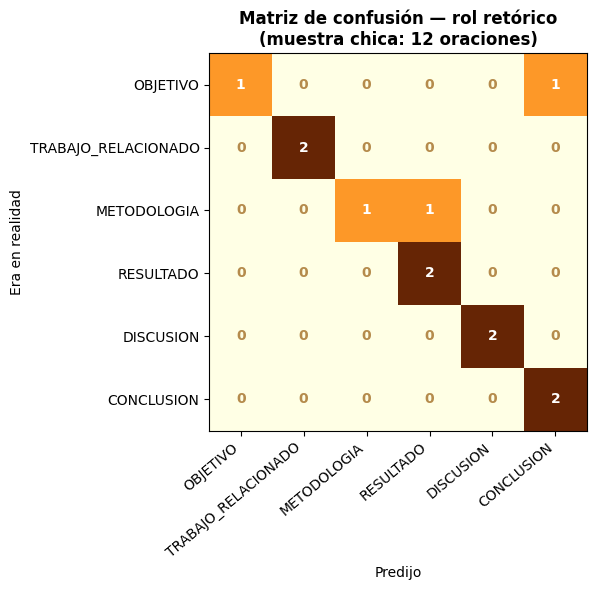


🏁 De 17% a 83% de aciertos con solo afinar. ✅


In [ ]:
def matriz_confusion_rol():
    n = len(CLASES_ROL)
    M = np.zeros((n, n), dtype=int)
    for t, c in oraciones_prueba:
        M[clase2id_rol[c]][clase2id_rol[despues_pred_rol[t]]] += 1
    fig, ax = plt.subplots(figsize=(6.5, 6))
    ax.imshow(M, cmap="YlOrBr")
    ax.set_xticks(range(n)); ax.set_xticklabels(CLASES_ROL, rotation=40, ha="right")
    ax.set_yticks(range(n)); ax.set_yticklabels(CLASES_ROL)
    ax.set_xlabel("Predijo"); ax.set_ylabel("Era en realidad")
    ax.set_title("Matriz de confusión — rol retórico\n(muestra chica: 12 oraciones)", weight="bold")
    for i in range(n):
        for j in range(n):
            ax.text(j, i, M[i][j], ha="center", va="center",
                    color="white" if M[i][j] else "#b58b4c", weight="bold")
    fig.tight_layout()
    return fig

fig_matriz_rol = matriz_confusion_rol()
fig_matriz_rol.savefig("/content/matriz_rol.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"\n🏁 De {antes_acc_rol}% a {despues_acc_rol}% de aciertos con solo afinar. ✅")

In [ ]:
from sklearn.metrics import classification_report

y_real = [clase2id_rol[c] for t, c in oraciones_prueba]
y_pred = [clase2id_rol[despues_pred_rol[t]] for t, c in oraciones_prueba]

print(classification_report(y_real, y_pred, target_names=CLASES_ROL, zero_division=0))

                     precision    recall  f1-score   support

           OBJETIVO       1.00      0.50      0.67         2
TRABAJO_RELACIONADO       1.00      1.00      1.00         2
        METODOLOGIA       1.00      0.50      0.67         2
          RESULTADO       0.67      1.00      0.80         2
          DISCUSION       1.00      1.00      1.00         2
         CONCLUSION       0.67      1.00      0.80         2

           accuracy                           0.83        12
          macro avg       0.89      0.83      0.82        12
       weighted avg       0.89      0.83      0.82        12



### Paso 9.5 · Afinar el tono del tutor con LoRA (demostración sobre TinyLlama)

Aquí LoRA no clasifica nada, afina directamente el modelo generativo para que aprenda un tono consistente. Seguimos la misma estructura que el notebook Hands-On, adaptada a explicaciones de conceptos de ML.

#### 9.5.1 · Instalar lo que falta
trl trae SFTTrainer (el entrenador especializado para afinar modelos generativos) y accelerate es lo que permite device_map="auto" al cargar el modelo (coloca las capas automáticamente en GPU si Colab te asignó una, o en CPU si no).

In [ ]:
%%capture
!pip install trl accelerate --quiet

#### 9.5.2 · Cargar TinyLlama base

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

modelo_base_tutor = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

tokenizer_tutor = AutoTokenizer.from_pretrained(modelo_base_tutor)
modelo_tutor = AutoModelForCausalLM.from_pretrained(
    modelo_base_tutor, dtype=torch.float16, device_map="auto")
print("Modelo base cargado:", modelo_base_tutor)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Modelo base cargado: TinyLlama/TinyLlama-1.1B-Chat-v1.0


In [ ]:
def generar_respuesta_tutor(modelo_a_usar, pregunta, max_new_tokens=80):
    mensajes = [{"role": "user", "content": pregunta}]
    prompt_formateado = tokenizer_tutor.apply_chat_template(mensajes, tokenize=False, add_generation_prompt=True)
    entrada = tokenizer_tutor(prompt_formateado, return_tensors="pt").to(modelo_a_usar.device)
    salida = modelo_a_usar.generate(
        **entrada, max_new_tokens=max_new_tokens, do_sample=False,
        pad_token_id=tokenizer_tutor.eos_token_id, no_repeat_ngram_size=3,
    )
    tokens_nuevos = salida[0][entrada["input_ids"].shape[1]:]
    return tokenizer_tutor.decode(tokens_nuevos, skip_special_tokens=True).strip()

#### 9.5.3 · Dataset: pares (pregunta sobre un concepto → explicación en voz de tutor)

In [ ]:
def formatear_ejemplo_tutor(pregunta, respuesta):
    mensajes = [
        {"role": "user", "content": pregunta},
        {"role": "assistant", "content": respuesta}
    ]
    return tokenizer_tutor.apply_chat_template(mensajes, tokenize=False)

pares_tutor = [
    ("¿Qué es el overfitting?",
     "¡Buena pregunta! Overfitting es cuando el modelo memoriza los datos de entrenamiento en vez de aprender el patrón general, así que le va mal con datos nuevos. ¿Quieres ver dónde aparece esto en el paper?"),
    ("¿Qué es la regularización L1?",
     "L1 suma el valor absoluto de los pesos a la función de pérdida, y tiende a volver algunos pesos exactamente cero, funcionando casi como un selector de variables. ¿Seguimos?"),
    ("¿Para qué sirve la regularización L2?",
     "L2 penaliza pesos muy grandes durante el entrenamiento para evitar que el modelo se sobreajuste. Es de las técnicas más comunes para controlar el overfitting. ¿Seguimos con la siguiente sección?"),
    ("¿Qué es la validación cruzada?",
     "Es dividir los datos en varias partes, entrenar con unas y evaluar con la restante, rotando cuál se usa para evaluar. Así mides qué tan bien generaliza el modelo. ¿Te late si vemos cómo la usó este paper?"),
    ("¿Qué es el descenso de gradiente?",
     "Es el algoritmo que ajusta los pesos del modelo dando pasos en la dirección que más reduce el error. Prácticamente todo el entrenamiento moderno se basa en esto. ¿Quieres que sigamos?"),
    ("¿Qué significa learning rate?",
     "Es el tamaño del paso que da el modelo al ajustar sus pesos en cada iteración. Muy alto y el entrenamiento se vuelve inestable; muy bajo y avanza demasiado lento. ¿Te gustaría que revisemos qué valor usó este paper?"),
    ("¿Qué es el batch size?",
     "Es cuántos ejemplos usa el modelo para calcular cada paso de actualización de sus pesos. Afecta la velocidad y estabilidad del entrenamiento. ¿Avanzamos?"),
    ("¿Qué es una epoch?",
     "Es una pasada completa del modelo por todos los datos de entrenamiento. Los modelos suelen necesitar varias para aprender bien. ¿Seguimos con lo siguiente?"),
    ("¿Qué es la función de pérdida?",
     "Mide qué tan lejos están las predicciones del modelo de los valores reales; entrenar es básicamente minimizar esa pérdida poco a poco. ¿Quieres ver cuál usó este estudio?"),
    ("¿Qué es cross-entropy?",
     "Es la función de pérdida estándar para clasificación: castiga fuerte cuando el modelo está muy seguro de una respuesta que resultó incorrecta. ¿Seguimos?"),
    ("¿Qué es el MSE?",
     "Es el error cuadrático medio, la función de pérdida más común para tareas de regresión. Penaliza más los errores grandes que los chicos. ¿Avanzamos?"),
    ("¿Qué es la precisión en clasificación?",
     "De todo lo que el modelo predijo como positivo, la precisión mide qué proporción realmente lo era. ¿Quieres que veamos la precisión que reportó este paper?"),
    ("¿Qué es el recall?",
     "De todo lo que realmente era positivo, el recall mide cuánto logró detectar el modelo. Suele haber un balance entre precisión y recall. ¿Seguimos?"),
    ("¿Qué es el F1-score?",
     "Es la media armónica entre precisión y recall, muy útil cuando las clases están desbalanceadas. ¿Te late revisar el F1 de este estudio?"),
    ("¿Qué es una matriz de confusión?",
     "Es una tabla que cruza lo que el modelo predijo contra lo que realmente era, mostrando aciertos y en qué se confunde. ¿Vemos la de este paper?"),
    ("¿Qué es una CNN?",
     "Es una red neuronal convolucional, especializada en datos con estructura espacial como imágenes, usando filtros que se deslizan sobre la entrada. ¿Seguimos?"),
    ("¿Qué diferencia hay entre RNN, LSTM y GRU?",
     "Las tres procesan datos secuenciales, pero LSTM y GRU agregan mecanismos de memoria para recordar información de pasos anteriores mejor que una RNN simple. ¿Avanzamos?"),
    ("¿Qué es un Transformer?",
     "Es una arquitectura basada en atención, no en recurrencia, que procesa toda la secuencia en paralelo. Es la base de modelos como BERT y GPT. ¿Seguimos con lo siguiente?"),
    ("¿Qué es el mecanismo de atención?",
     "Permite al modelo enfocarse en las partes más relevantes de la entrada al procesar cada elemento de la secuencia. ¿Quieres que veamos cómo lo usa este paper?"),
    ("¿Qué es transfer learning?",
     "Es reutilizar un modelo ya entrenado en una tarea grande como punto de partida para una tarea nueva y más específica. ¿Seguimos?"),
    ("¿Qué es fine-tuning?",
     "Es ajustar los pesos de un modelo preentrenado usando un dataset más chico y específico de tu tarea, en vez de entrenar desde cero. Es justo lo que estamos haciendo aquí mismo. ¿Avanzamos?"),
    ("¿Qué es LoRA?",
     "Es una técnica de fine-tuning eficiente que congela los pesos originales del modelo y solo entrena matrices pequeñas agregadas a ciertas capas, reduciendo muchísimo los parámetros a entrenar. ¿Seguimos con la siguiente sección?"),
    ("¿Qué es un embedding?",
     "Es una representación numérica de un texto, donde cosas con significado parecido quedan cerca en el espacio vectorial. Así es como se puede buscar por significado y no por palabra exacta. ¿Avanzamos?"),
    ("¿Qué es la similitud coseno?",
     "Mide qué tan parecidos son dos vectores según el ángulo entre ellos, y es la forma más común de comparar embeddings. ¿Seguimos?"),
    ("¿Qué es un p-valor?",
     "Es la probabilidad de observar un resultado igual o más extremo asumiendo que no hay efecto real; un p-valor bajo se suele interpretar como evidencia en contra de esa hipótesis nula. ¿Te late que veamos el que reportó este estudio?"),
    ("¿Qué es un baseline?",
     "Es un modelo o método simple que se usa como punto de referencia, para saber si un modelo nuevo realmente representa una mejora. ¿Seguimos?"),
    ("¿Qué significa SOTA?",
     "Son las siglas de 'state of the art': el mejor resultado reportado hasta el momento en una tarea o benchmark específico. ¿Avanzamos?"),
    ("¿Qué es un ablation study?",
     "Es un experimento donde se quita o desactiva una parte del modelo para medir cuánto contribuía esa parte al resultado final. ¿Quieres que veamos si este paper hizo uno?"),
    ("¿Qué es un hiperparámetro?",
     "Es un valor que tú defines antes de entrenar (como el learning rate o el batch size), a diferencia de los pesos, que el modelo aprende solo. ¿Seguimos?"),
    ("¿Qué es el dropout?",
     "Es una técnica de regularización que apaga aleatoriamente algunas neuronas durante el entrenamiento, para evitar que el modelo dependa demasiado de unas pocas. ¿Avanzamos con lo que sigue?"),
]

from datasets import Dataset
ejemplos_tutor = [{"texto": formatear_ejemplo_tutor(p, r)} for p, r in pares_tutor]
dataset_tutor = Dataset.from_list(ejemplos_tutor)
print(len(pares_tutor), "pares de entrenamiento para el tono del tutor ✅")
dataset_tutor

30 pares de entrenamiento para el tono del tutor ✅


Dataset({
    features: ['texto'],
    num_rows: 30
})

#### 9.5.4 · Probar el modelo ANTES de afinar

In [ ]:
prompt_prueba_tutor = "¿Qué es el overfitting?"
respuesta_base_tutor = generar_respuesta_tutor(modelo_tutor, prompt_prueba_tutor)
print("ANTES de afinar:\n", respuesta_base_tutor)

ANTES de afinar:
 El overfiting es la tendencia de los modelos de aprendizaje automático a aprender una sola o varias características de los datos, lo que puede resultar en un modelo confuso y ineficiente. El overfitter puede ser un problema en el proceso de aprender, ya que puede ser más difícil de resolver y puede producir


#### 9.5.5 · Configurar LoRA (CAUSAL_LM)

In [ ]:
from peft import LoraConfig, get_peft_model
from transformers import set_seed
set_seed(42)

config_lora_tutor = LoraConfig(
    r=8, lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.0,
    task_type="CAUSAL_LM"
)
modelo_tutor_lora = get_peft_model(modelo_tutor, config_lora_tutor)
modelo_tutor_lora.print_trainable_parameters()

trainable params: 1,126,400 || all params: 1,101,174,784 || trainable%: 0.1023


#### 9.5.6 · Entrenar con SFTTrainer


In [ ]:
from trl import SFTTrainer, SFTConfig

config_entrenamiento_tutor = SFTConfig(
    output_dir="/content/tutor_lora_resultados",
    num_train_epochs=15,
    per_device_train_batch_size=6,
    learning_rate=2e-4,
    logging_steps=2,
    dataset_text_field="texto",
    max_length=128,
    report_to="none",
)

trainer_tutor = SFTTrainer(
    model=modelo_tutor_lora,
    train_dataset=dataset_tutor,
    args=config_entrenamiento_tutor,
)

resultado_tutor = trainer_tutor.train()
perdida_inicial_tutor = trainer_tutor.state.log_history[0]['loss']
perdida_final_tutor = trainer_tutor.state.log_history[-2]['loss']
print(f"Pérdida al inicio: {perdida_inicial_tutor:.2f}")
print(f"Pérdida final: {perdida_final_tutor:.2f}")
print(f"Reducción: {(1 - perdida_final_tutor/perdida_inicial_tutor) * 100:.0f}%")

Adding EOS to train dataset:   0%|          | 0/30 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/30 [00:00<?, ? examples/s]

Building labels for train dataset:   0%|          | 0/30 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/30 [00:00<?, ? examples/s]

Dropping fully masked examples from train dataset:   0%|          | 0/30 [00:00<?, ? examples/s]

{'loss': '3.147', 'grad_norm': '2.288', 'learning_rate': '0.0001973', 'entropy': '1.865', 'num_tokens': '872', 'mean_token_accuracy': '0.4779', 'epoch': '0.4'}
{'loss': '3.081', 'grad_norm': '2.179', 'learning_rate': '0.000192', 'entropy': '1.866', 'num_tokens': '1789', 'mean_token_accuracy': '0.4774', 'epoch': '0.8'}
{'loss': '3.048', 'grad_norm': '2.402', 'learning_rate': '0.0001867', 'entropy': '1.91', 'num_tokens': '2700', 'mean_token_accuracy': '0.4576', 'epoch': '1.2'}
{'loss': '2.842', 'grad_norm': '2.545', 'learning_rate': '0.0001813', 'entropy': '1.965', 'num_tokens': '3623', 'mean_token_accuracy': '0.4819', 'epoch': '1.6'}
{'loss': '2.542', 'grad_norm': '2.947', 'learning_rate': '0.000176', 'entropy': '1.906', 'num_tokens': '4544', 'mean_token_accuracy': '0.5204', 'epoch': '2'}
{'loss': '2.387', 'grad_norm': '2.86', 'learning_rate': '0.0001707', 'entropy': '1.952', 'num_tokens': '5476', 'mean_token_accuracy': '0.5301', 'epoch': '2.4'}
{'loss': '2.202', 'grad_norm': '2.465', '

#### 9.5.7 · Comparar ANTES vs. DESPUÉS (mismo prompt)

In [ ]:
respuesta_afinada_tutor = generar_respuesta_tutor(modelo_tutor_lora, prompt_prueba_tutor)
print("ANTES de afinar:\n", respuesta_base_tutor)
print("\nDESPUÉS de afinar:\n", respuesta_afinada_tutor)

ANTES de afinar:
 El overfiting es la tendencia de los modelos de aprendizaje automático a aprender una sola o varias características de los datos, lo que puede resultar en un modelo confuso y ineficiente. El overfitter puede ser un problema en el proceso de aprender, ya que puede ser más difícil de resolver y puede producir

DESPUÉS de afinar:
 Escape, and the 


<<|user:

 
< < < < 
 1.


Se observa que sí hay una reducción del error, sin embargo por ser pocos ejemplos para LoRa la respuesta generada no es congruente. Lo importante es visibilizar la reducción del error.

#### 9.5.8 · Guardar el adaptador

In [ ]:
modelo_tutor_lora.save_pretrained("/content/tutor_tono_lora")
print("Adaptador LoRA del tono guardado ✅")

Adaptador LoRA del tono guardado ✅


## Paso 10 · La voz del tutor (prompt) + el pipeline completo
El rol retórico decide cómo explicar. La "regla de oro híbrida" (fuente verificada primero, conocimiento general marcado como respaldo) es la que cumple el papel de "no inventar en lo delicado".

### 10.1 · El prompt del tutor

In [ ]:
SYSTEM_TUTOR = """Eres un tutor que ayuda a un estudiante a entender artículos científicos, sección por sección. Tu chamba es explicar con claridad y calidez, sin sonar acartonado.

FORMATO OBLIGATORIO — TU RESPUESTA DEBE EMPEZAR CON UNA DE ESTAS TRES ETIQUETAS EXACTAS, EN SU PROPIA LÍNEA, ANTES DE CUALQUIER OTRA COSA:
[FUENTE: PAPER] → si el dato viene del CONTEXTO DEL PAPER de abajo.
[FUENTE: GLOSARIO] → si el dato viene del CONTEXTO DEL GLOSARIO de abajo.
[FUENTE: GENERAL] → si el concepto NO aparece en ninguno de los dos contextos y estás respondiendo con tu conocimiento general.

Si usas [FUENTE: GENERAL], tu primera frase después de la etiqueta DEBE avisar honestamente que ese dato no está en el paper ni en el glosario curado, antes de dar la explicación.
Nunca uses [FUENTE: PAPER] o [FUENTE: GLOSARIO] si el contexto correspondiente está vacío o dice "sin coincidencias" — en ese caso, usa [FUENTE: GENERAL] obligatoriamente.
Si usas tanto el paper como el glosario, elige la etiqueta de la fuente principal y menciona la otra en el texto.

REGLA DE ORO — NO INVENTAR:
- Nunca inventes resultados, cifras o afirmaciones que el paper no hace.
- Usa exactamente los datos que aparecen en el contexto correspondiente a tu etiqueta.

CÓMO EXPLICAR SEGÚN EL TIPO DE SECCIÓN (rol retórico detectado):
- OBJETIVO / TRABAJO_RELACIONADO: enfócate en el "por qué" — qué problema atacan y qué vacío llenan.
- METODOLOGIA: enfócate en el "cómo" — qué se hizo, con qué configuración o datos.
- RESULTADO: enfócate en interpretar los números o hallazgos, no solo repetirlos.
- DISCUSION / CONCLUSION: enfócate en las implicaciones y limitaciones.
- Si no aplica ninguno (pregunta libre del estudiante), simplemente responde con claridad.

VOZ:
- Cálido, breve (2 a 4 frases después de la etiqueta), en español, sin tecnicismos innecesarios.
- Si defines un concepto, dalo con una analogía simple cuando ayude a entenderlo.
- Cierra ofreciendo profundizar o seguir con la siguiente sección.

ROL RETÓRICO DE ESTE FRAGMENTO: {rol}

CONTEXTO DEL PAPER:
{contexto_paper}

CONTEXTO DEL GLOSARIO (definiciones relevantes encontradas):
{contexto_glosario}

PREGUNTA O FRAGMENTO A EXPLICAR:
{mensaje}"""

import re

def separar_fuente(respuesta_cruda):
    """Extrae la etiqueta [FUENTE: ...] del inicio de la respuesta, si existe."""
    m = re.match(r"\[FUENTE:\s*(PAPER|GLOSARIO|GENERAL)\]\s*", respuesta_cruda)
    if m:
        return m.group(1), respuesta_cruda[m.end():].strip()
    return "SIN_ETIQUETA", respuesta_cruda  # el modelo no siguió el formato — señal de que hay que revisar el prompt

def responder_tutor(mensaje, contexto_paper, contexto_glosario, rol="No aplica (pregunta libre)"):
    prompt = (SYSTEM_TUTOR
              .replace("{rol}", rol)
              .replace("{contexto_paper}", contexto_paper or "(vacío)")
              .replace("{contexto_glosario}", contexto_glosario or "(sin coincidencias en el glosario)")
              .replace("{mensaje}", mensaje))
    crudo = preguntar_a_groq(prompt, temperatura=0.4)
    fuente, texto = separar_fuente(crudo)
    return {"fuente": fuente, "explicacion": texto}

### 10.2 · Modo 1 — Explicar una sección del paper

Este es el flujo que responde directamente al objetivo: "dado un artículo científico, ayúdame a estudiarlo sección por sección, desarrollando los conceptos desconocidos". Aquí sí tiene sentido pleno usar clasificar_rol — el fragmento es una oración/chunk real del paper, exactamente el tipo de texto para el que entrenamos el clasificador en los Pasos 6-9. Y buscar_definicion(texto, k=2) busca en el glosario usando el propio fragmento como consulta — así, si el chunk menciona "regularización L2" o "cross-entropy", el RAG externo trae esas definiciones automáticamente, sin que el estudiante tenga que pedirlas explícitamente.

In [ ]:
def explicar_fragmento(indice_seccion):
    """
    Toma una sección ya indexada del paper (por su posición en secciones_paper, Paso 5),
    clasifica su rol retórico, busca definiciones relevantes en el glosario,
    y genera la explicación pedagógica.
    """
    fragmento = secciones_paper[indice_seccion]
    texto = fragmento["texto"]
    pagina = fragmento["pagina"]

    rol = clasificar_rol(texto)
    definiciones = buscar_definicion(texto, k=2)
    contexto_glosario = "\n\n".join(definiciones)
    contexto_paper = f"[Página {pagina}]\n{texto}"

    resultado = responder_tutor(mensaje=texto, contexto_paper=contexto_paper,
                                 contexto_glosario=contexto_glosario, rol=rol)
    return {"pagina": pagina, "rol": rol, "texto_original": texto,
            "contexto_paper": contexto_paper, "contexto_glosario": contexto_glosario,
            "fuente": resultado["fuente"], "explicacion": resultado["explicacion"]}

### 10.3 · Modo 2 — Pregunta libre del estudiante
Por qué no clasificar rol retórico aquí: una pregunta del estudiante como "¿qué significa overfitting?" no tiene un rol retórico propio en el mismo sentido que una oración del paper — el clasificador se entrenó para etiquetar afirmaciones de un artículo (Paso 6), no preguntas de un lector. Forzar la clasificación aquí le daría al modelo una etiqueta sin sentido real. Por eso responder_tutor recibe el valor por defecto "No aplica (pregunta libre)" para el parámetro rol en este modo — el prompt ya sabe manejarlo (última línea del bloque "CÓMO EXPLICAR").

In [ ]:
def preguntar_tutor(pregunta):
    """
    Para cuando el estudiante hace una pregunta suelta ("¿qué significa X?",
    "¿cómo evaluaron esto?") en vez de pedir explicación de un fragmento concreto.
    """
    fragmentos = buscar_en_paper(pregunta, k=3)
    contexto_paper = "\n\n".join(f"[Página {f['pagina']}] {f['texto']}" for f in fragmentos)
    definiciones = buscar_definicion(pregunta, k=2)
    contexto_glosario = "\n\n".join(definiciones)

    resultado = responder_tutor(pregunta, contexto_paper, contexto_glosario)
    return {"contexto_paper": contexto_paper, "contexto_glosario": contexto_glosario,
            "fuente": resultado["fuente"], "explicacion": resultado["explicacion"]}

### 10.4 · Prueba de ambos modos

In [ ]:
# Modo 1: explicar una sección real del paper
r1 = explicar_fragmento(0)  # ajusta el índice a una sección real una vez que tengas un PDF cargado
print(f"[Página {r1['pagina']}] · Rol detectado: {r1['rol']}")
print(f"{r1['explicacion']}\n")

# Modo 2: pregunta libre
r2 = preguntar_tutor("¿Qué significa overfitting y por qué es un problema?")
print(f"{r2['explicacion']}")

[Página 1] · Rol detectado: METODOLOGIA
Este fragmento corresponde a la información bibliográfica del artículo: revista, año, volumen, páginas, DOI, ISSN, título, autores y afiliación. No contiene detalles sobre la metodología, solo identifica el documento y sus autores. Si necesitas profundizar en la sección de metodología del paper, avísame y te explico esa parte.

El overfitting, o sobreajuste, ocurre cuando un modelo aprende tan bien los datos de entrenamiento que termina memorizar ruido y detalles específicos en lugar de captar patrones generales. Esto se ve cuando el error de entrenamiento sigue bajando mientras el error de validación empieza a subir. El problema es que el modelo deja de generalizar bien a datos nuevos, por lo que su rendimiento en situaciones reales se degrada. Si quieres profundizar en cómo evitarlo o en técnicas de regularización, dime y seguimos.


## Paso 11 · El juez (fidelidad + manejo honesto de ausencia + claridad)

In [ ]:
import json as _json  # faltaba esta línea — es lo que _json.loads() necesita para existir

PROMPT_JUEZ_TUTOR = """Eres un juez de calidad para un tutor de artículos científicos. Vas a calificar la explicación del tutor.

Recibes:
- PREGUNTA/FRAGMENTO: {pregunta}
- CONTEXTO DEL PAPER (puede estar vacío): {contexto_paper}
- CONTEXTO DEL GLOSARIO (puede decir "sin coincidencias"): {contexto_glosario}
- FUENTE QUE EL TUTOR DECLARÓ HABER USADO: {fuente_declarada}
- RESPUESTA DEL TUTOR (ya sin la etiqueta de fuente, solo el texto explicativo): {respuesta}

Califica DOS cosas, del 1 al 5:

1) fidelidad — el criterio depende de la FUENTE QUE EL TUTOR DECLARÓ:
   - Si la fuente declarada es PAPER o GLOSARIO: califica qué tan consistente es la respuesta con el contexto correspondiente. 5 = usa el dato exacto sin inventar; 1 = contradice o inventa.
   - Si la fuente declarada es GENERAL: NO la compares contra el paper ni el glosario (se espera que no estén ahí, eso ya es correcto). En su lugar, califica si la explicación es correcta y precisa según el conocimiento general aceptado del tema. 5 = información correcta y bien fundamentada; 1 = información falsa o inventada de forma irresponsable.

2) claridad: ¿es comprensible para alguien que no conoce el concepto, breve y con buen tono?

Devuelve ÚNICAMENTE un JSON válido, sin texto extra, con esta forma exacta:
{
  "fidelidad": <1-5>,
  "claridad": <1-5>,
  "comentario": "<una frase corta en español explicando la calificación>"
}"""

def juzgar_tutor(pregunta, contexto_paper, contexto_glosario, respuesta, fuente_declarada):
    prompt = (PROMPT_JUEZ_TUTOR
              .replace("{pregunta}", pregunta)
              .replace("{contexto_paper}", contexto_paper or "(vacío)")
              .replace("{contexto_glosario}", contexto_glosario or "(sin coincidencias en el glosario)")
              .replace("{fuente_declarada}", fuente_declarada)
              .replace("{respuesta}", respuesta))
    crudo = preguntar_a_groq(prompt, temperatura=0.0)
    try:
        ini, fin = crudo.find("{"), crudo.rfind("}")
        return _json.loads(crudo[ini:fin+1])
    except Exception:
        return {"fidelidad": None, "claridad": None, "comentario": crudo[:120]}


def fuente_es_correcta(fuente_declarada, debe_estar_en_fuentes):
    if debe_estar_en_fuentes:
        return fuente_declarada in ("PAPER", "GLOSARIO")
    return fuente_declarada == "GENERAL"


PREGUNTAS_JUEZ_TUTOR = [
    {"pregunta": "¿Qué es el overfitting?", "debe_estar_en_fuentes": True},
    {"pregunta": "¿Qué es LoRA?", "debe_estar_en_fuentes": True},
    {"pregunta": "¿Qué es la destilación de conocimiento (knowledge distillation)?", "debe_estar_en_fuentes": False},
]

resultados_juez_tutor = []
for item in PREGUNTAS_JUEZ_TUTOR:
    r = preguntar_tutor(item["pregunta"])
    v = juzgar_tutor(item["pregunta"], r["contexto_paper"], r["contexto_glosario"], r["explicacion"], r["fuente"])
    correcto = fuente_es_correcta(r["fuente"], item["debe_estar_en_fuentes"])
    resultados_juez_tutor.append({"pregunta": item["pregunta"], "respuesta": r["explicacion"],
                                   "fuente_declarada": r["fuente"], "manejo_de_ausencia": correcto, **v})
    print("❓", item["pregunta"], f"(¿debía estar en fuentes?: {'Sí' if item['debe_estar_en_fuentes'] else 'No'})")
    print("   🏷️  Fuente declarada:", r["fuente"], "·", ("✅ correcto" if correcto else "❌ incorrecto"))
    print("   🧑‍🏫", r["explicacion"])
    print("   🧑‍⚖️ fidelidad:", v.get("fidelidad"), "· claridad:", v.get("claridad"), "·", v.get("comentario"), "\n")

_fidelidades_validas = [r["fidelidad"] for r in resultados_juez_tutor if isinstance(r.get("fidelidad"), (int, float))]
_tasa_manejo = round(100 * sum(r["manejo_de_ausencia"] for r in resultados_juez_tutor) / len(resultados_juez_tutor))

if _fidelidades_validas:
    _fidelidad_prom = round(sum(_fidelidades_validas) / len(_fidelidades_validas), 1)
    print("⭐ Fidelidad promedio:", _fidelidad_prom, "/ 5")
else:
    _fidelidad_prom = None
    print("⚠️ Ninguna calificación de fidelidad se pudo interpretar — revisa la salida cruda del juez arriba.")

print("✅ Manejo correcto de fuente/ausencia:", _tasa_manejo, "%")

❓ ¿Qué es el overfitting? (¿debía estar en fuentes?: Sí)
   🏷️  Fuente declarada: GLOSARIO · ✅ correcto
   🧑‍🏫 El overfitting, o sobreajuste, es cuando un modelo aprende demasiado bien los datos de entrenamiento, hasta memorizar ruido y detalles específicos, en lugar de capturar patrones generales. Como resultado, su rendimiento se deteriora con datos nuevos que no ha visto.  
Imagina que un estudiante memorizó todas las respuestas de un examen de práctica, pero no entendió los conceptos; al enfrentarse a un examen real, falla porque no puede aplicar lo aprendido a situaciones nuevas.  

¿Te gustaría profundizar en cómo evitarlo o en ejemplos concretos?
   🧑‍⚖️ fidelidad: 5 · claridad: 5 · Respuesta clara y fiel al glosario. 

❓ ¿Qué es LoRA? (¿debía estar en fuentes?: Sí)
   🏷️  Fuente declarada: GLOSARIO · ✅ correcto
   🧑‍🏫 LoRA (Low‑Rank Adaptation) es una técnica de fine‑tuning eficiente que congela los pesos originales del modelo y solo entrena matrices pequeñas de bajo rango agre

## Paso 12 · La app de Gradio

In [ ]:
import pandas as pd

def analizar_paper_cargado(secciones):
    """Corre el clasificador de rol sobre TODOS los fragmentos del paper cargado
    y regresa la distribución de roles + la confianza promedio del modelo."""
    conteo = {c: 0 for c in CLASES_ROL}
    confianzas = []
    for frag in secciones:
        inputs = tokenizer_rol(frag["texto"], return_tensors="pt", truncation=True, max_length=128).to(modelo_rol.device)
        modelo_rol.eval()
        with torch.no_grad():
            probs = modelo_rol(**inputs).logits.softmax(dim=-1)[0]
        idx = int(probs.argmax())
        conteo[id2clase_rol[idx]] += 1
        confianzas.append(float(probs[idx]))
    confianza_promedio = sum(confianzas) / len(confianzas) if confianzas else 0.0
    df_roles = pd.DataFrame({"rol": list(conteo.keys()), "fragmentos": list(conteo.values())})
    return df_roles, confianza_promedio


def actualizar_contador_fuente(contador, fuente):
    """Suma 1 a la fuente usada en esta interacción, sin mutar el estado anterior directamente."""
    nuevo = dict(contador)
    nuevo[fuente] = nuevo.get(fuente, 0) + 1
    return nuevo


def resumen_fuentes(contador):
    total = sum(contador.values())
    if total == 0:
        return "Aún no se ha hecho ninguna consulta sobre este paper."
    partes = [f"**{k}**: {v} ({round(100*v/total)}%)" for k, v in contador.items() if v > 0]
    return "🏷️ **Fuentes usadas en esta sesión:** " + " · ".join(partes)

In [ ]:
import gradio as gr

# --- Indexar el PDF subido, guardándolo en el estado de la sesión (no en variables globales) ---
def indexar_pdf_para_app(archivo):
    contador_vacio = {"PAPER": 0, "GLOSARIO": 0, "GENERAL": 0}
    if archivo is None:
        return (None, gr.update(choices=[], value=None), "Sube un PDF para empezar 📄",
                None, "Sube un PDF para ver este análisis.", contador_vacio, resumen_fuentes(contador_vacio))

    paginas = extraer_texto_pdf(archivo.name)
    secciones = trocear_paper(paginas)
    if not secciones:
        return (None, gr.update(choices=[], value=None), "No se pudo extraer texto de este PDF 😕",
                None, "Sube un PDF para ver este análisis.", contador_vacio, resumen_fuentes(contador_vacio))

    textos = [c["texto"] for c in secciones]
    embeddings = buscador.encode(textos, convert_to_tensor=True)
    estado = {"secciones": secciones, "embeddings": embeddings}
    opciones = [f"{i+1}. [Pág. {c['pagina']}] {c['texto'][:70]}…" for i, c in enumerate(secciones)]

    df_roles, confianza_promedio = analizar_paper_cargado(secciones)
    texto_confianza = f"**Confianza promedio del clasificador en este paper:** {confianza_promedio:.0%}"

    return (estado, gr.update(choices=opciones, value=opciones[0]), f"{len(secciones)} fragmentos indexados ✅",
            df_roles, texto_confianza, contador_vacio, resumen_fuentes(contador_vacio))

In [ ]:
def explicar_desde_estado(estado, seleccion, contador_fuente):
    if estado is None or seleccion is None:
        return "", "Sube un PDF y elige una sección primero.", "", contador_fuente, resumen_fuentes(contador_fuente)

    indice = int(seleccion.split(".")[0]) - 1
    fragmento = estado["secciones"][indice]
    texto, pagina = fragmento["texto"], fragmento["pagina"]

    rol = clasificar_rol(texto)
    contexto_glosario = "\n\n".join(buscar_definicion(texto, k=2))
    contexto_paper = f"[Página {pagina}]\n{texto}"

    resultado = responder_tutor(texto, contexto_paper, contexto_glosario, rol=rol)
    contador_fuente = actualizar_contador_fuente(contador_fuente, resultado["fuente"])
    badges = f"🏷️ **Rol:** {rol}  ·  📚 **Fuente:** {resultado['fuente']}"

    return texto, badges, resultado["explicacion"], contador_fuente, resumen_fuentes(contador_fuente)


def preguntar_desde_estado(estado, pregunta, contador_fuente):
    if not pregunta or not pregunta.strip():
        return "", "", contador_fuente, resumen_fuentes(contador_fuente)

    if estado is not None:
        emb_q = buscador.encode(pregunta, convert_to_tensor=True)
        hits = util.semantic_search(emb_q, estado["embeddings"], top_k=3)[0]
        fragmentos = [estado["secciones"][h["corpus_id"]] for h in hits]
        contexto_paper = "\n\n".join(f"[Página {f['pagina']}] {f['texto']}" for f in fragmentos)
    else:
        contexto_paper = ""
    contexto_glosario = "\n\n".join(buscar_definicion(pregunta, k=2))
    resultado = responder_tutor(pregunta, contexto_paper, contexto_glosario)
    contador_fuente = actualizar_contador_fuente(contador_fuente, resultado["fuente"])
    badges = f"📚 **Fuente:** {resultado['fuente']}"

    return badges, resultado["explicacion"], contador_fuente, resumen_fuentes(contador_fuente)

In [ ]:
CSS_TUTOR = """
.gradio-container {background:#F4F6FB !important;}
#banner {background:#FFFFFF;border:2px solid #DCE3F0;border-radius:20px;padding:22px 26px;
  box-shadow:0 6px 20px #a9b8d855;margin-bottom:8px;}
#banner h1 {color:#1F2A44;margin:0;font-size:28px;}
#banner p {color:#5B6B8C;margin:6px 0 0;font-size:15px;}
.tarjeta {background:#FFFFFF !important;border:2px solid #DCE3F0 !important;border-radius:16px !important;
  padding:16px !important;box-shadow:0 4px 14px #a9b8d833 !important;}

/* Respaldo por si el forzado de tema claro (demo.load más abajo) no llegara a ejecutarse */
.gradio-container, .gradio-container.dark {
  --body-text-color: #1F2A44 !important;
  --body-text-color-subdued: #5B6B8C !important;
}
.gradio-container .prose, .gradio-container .prose p, .gradio-container .prose li,
.gradio-container .prose strong, .gradio-container .prose h1, .gradio-container .prose h2,
.gradio-container .prose h3, .gradio-container label span {
  color:#1F2A44 !important;
}
"""

tema_tutor = gr.themes.Soft(primary_hue="indigo", secondary_hue="blue", neutral_hue="slate")


# ============================================================
# 7. La app
# ============================================================
with gr.Blocks(title="Tutor de Papers") as demo:

    # Fuerza el tema claro apenas carga la página (evita el bug de contraste en modo oscuro)
    demo.load(fn=None, inputs=None, outputs=None, js="""
        () => {
            const url = new URL(window.location.href);
            if (url.searchParams.get('__theme') !== 'light') {
                url.searchParams.set('__theme', 'light');
                window.location.replace(url.toString());
            }
        }
    """)

    gr.HTML('<div id="banner"><h1>🧑‍🏫 Tutor de Papers Científicos</h1>'
            '<p>Sube un artículo, elige una sección y te la explico con calma — citando el paper o el glosario cuando puedo.</p></div>')

    estado_paper = gr.State(None)
    contador_fuente = gr.State({"PAPER": 0, "GLOSARIO": 0, "GENERAL": 0})

    with gr.Tabs():
        with gr.Tab("📄 Estudiar el paper"):
            with gr.Row():
                with gr.Column(scale=45):
                    with gr.Group(elem_classes="tarjeta"):
                        archivo_pdf = gr.File(label="Sube tu PDF 📎", file_types=[".pdf"])
                        estado_msg = gr.Markdown("Sube un PDF para empezar 📄")
                        selector_seccion = gr.Dropdown(label="Secciones detectadas", choices=[], interactive=True)
                        boton_explicar = gr.Button("Explicar esta sección 🧑‍🏫", variant="primary")
                    gr.Markdown("#### O pregunta lo que quieras")
                    with gr.Group(elem_classes="tarjeta"):
                        pregunta_libre = gr.Textbox(label="Tu pregunta", lines=2,
                            placeholder="¿Qué significa X? ¿Cómo evaluaron Y?")
                        boton_preguntar = gr.Button("Preguntar 💬")
                with gr.Column(scale=55):
                    with gr.Group(elem_classes="tarjeta"):
                        gr.Markdown("#### Texto original del fragmento")
                        texto_original = gr.Textbox(show_label=False, lines=4, interactive=False)
                        badges_salida = gr.Markdown()
                        explicacion_salida = gr.Markdown()

        with gr.Tab("📊 ¿Cómo le fue?"):
            gr.Markdown("### Con el paper que tienes cargado")
            with gr.Row():
                with gr.Column():
                    grafico_roles = gr.BarPlot(x="rol", y="fragmentos",
                        title="Roles retóricos detectados en este paper", height=300)
                    confianza_md = gr.Markdown("Sube un PDF para ver este análisis.")
                with gr.Column():
                    resumen_fuentes_md = gr.Markdown("Aún no se ha hecho ninguna consulta sobre este paper.")
                    gr.Markdown("_Qué tan seguido el tutor pudo citar el paper o el glosario, frente a cuántas veces recurrió a conocimiento general._")

            gr.Markdown("---\n### Evaluación general del clasificador (datos de prueba fijos, no de este paper)")
            gr.Markdown("_Muestra de 12 oraciones de prueba, medida una sola vez al entrenar — es una demostración, no una métrica de producción ni específica de este documento._")
            _matriz_rol = "/content/matriz_rol.png" if os.path.exists("/content/matriz_rol.png") else None
            gr.Image(value=_matriz_rol, label="Matriz de confusión (rol retórico)", height=320)
            try:
                _resumen_juez = (f"**⭐ Fidelidad promedio:** {_fidelidad_prom} / 5  \n"
                                  f"**✅ Manejo correcto de fuente/ausencia:** {_tasa_manejo}% "
                                  f"en {len(resultados_juez_tutor)} preguntas de prueba.")
            except NameError:
                _resumen_juez = "Corre el **Paso 11** para ver el veredicto del juez."
            gr.Markdown(f"### 🧑‍⚖️ El juez dice:\n{_resumen_juez}")

    gr.Markdown("<center>Tutor de papers científicos · RAG + fine-tuning · Proyecto adaptado de El Comandero</center>")

    archivo_pdf.change(indexar_pdf_para_app, inputs=archivo_pdf,
                        outputs=[estado_paper, selector_seccion, estado_msg,
                                 grafico_roles, confianza_md, contador_fuente, resumen_fuentes_md])
    boton_explicar.click(explicar_desde_estado, inputs=[estado_paper, selector_seccion, contador_fuente],
                          outputs=[texto_original, badges_salida, explicacion_salida,
                                   contador_fuente, resumen_fuentes_md])
    boton_preguntar.click(preguntar_desde_estado, inputs=[estado_paper, pregunta_libre, contador_fuente],
                           outputs=[badges_salida, explicacion_salida, contador_fuente, resumen_fuentes_md])

demo.launch(share=True, debug=False, theme=tema_tutor, css=CSS_TUTOR)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://08b72eb85678002b6a.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
